# Exploratory Data Analysis: News Headlines Dataset for Sarcasm Detection
This notebook explores the dataset containing non-sarcastic (Huffington Post) and sarcastic (The Onion) news headlines. We will analyze class distribution, headline lengths, and common vocabulary to inform our preprocessing and baseline modeling steps.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords

# Download stopwords if not already present
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

[nltk_data] Downloading package stopwords to /home/junwu/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [2]:
DATA_PATH = "../data/raw/Sarcasm_Headlines_Dataset_v2.json"

try:
    df = pd.read_json(DATA_PATH, lines=True)
    print(f"Dataset loaded successfully with {len(df)} records.")
    display(df.head())
except FileNotFoundError:
    print("Dataset not found. Please ensure the Kaggle dataset is downloaded to the correct path.")
    
# Map labels to text for easier plotting
df['label_text'] = df['is_sarcastic'].map({0: 'Factual (HuffPost)', 1: 'Satirical (The Onion)'})

Dataset loaded successfully with 28619 records.


,is_sarcastic,headline,article_link
0,1,thirtysomething scientists unveil doomsday clo...,https://www.theonion.com/thirtysomething-scien...
1,0,dem rep. totally nails why congress is falling...,https://www.huffingtonpost.com/entry/donna-edw...
2,0,eat your veggies: 9 deliciously different recipes,https://www.huffingtonpost.com/entry/eat-your-...
3,1,inclement weather prevents liar from getting t...,https://local.theonion.com/inclement-weather-p...
4,1,mother comes pretty close to using word 'strea...,https://www.theonion.com/mother-comes-pretty-c...


/tmp/ipykernel_597614/1551141653.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='label_text', palette='viridis')


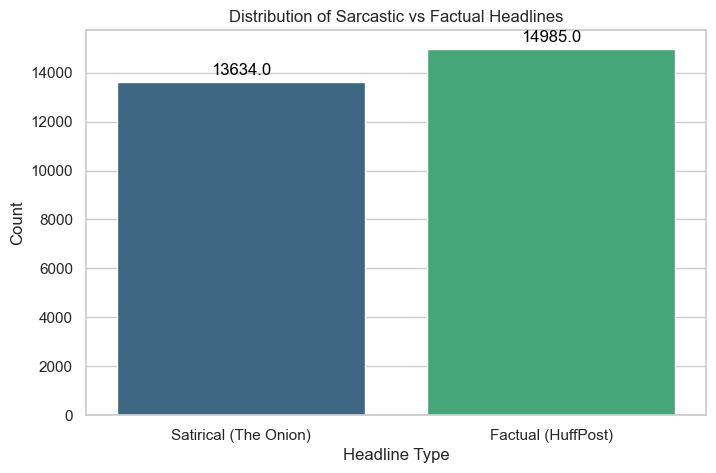

In [3]:
# Check if the dataset is balanced
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='label_text', palette='viridis')
plt.title('Distribution of Sarcastic vs Factual Headlines')
plt.xlabel('Headline Type')
plt.ylabel('Count')

# Add counts on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

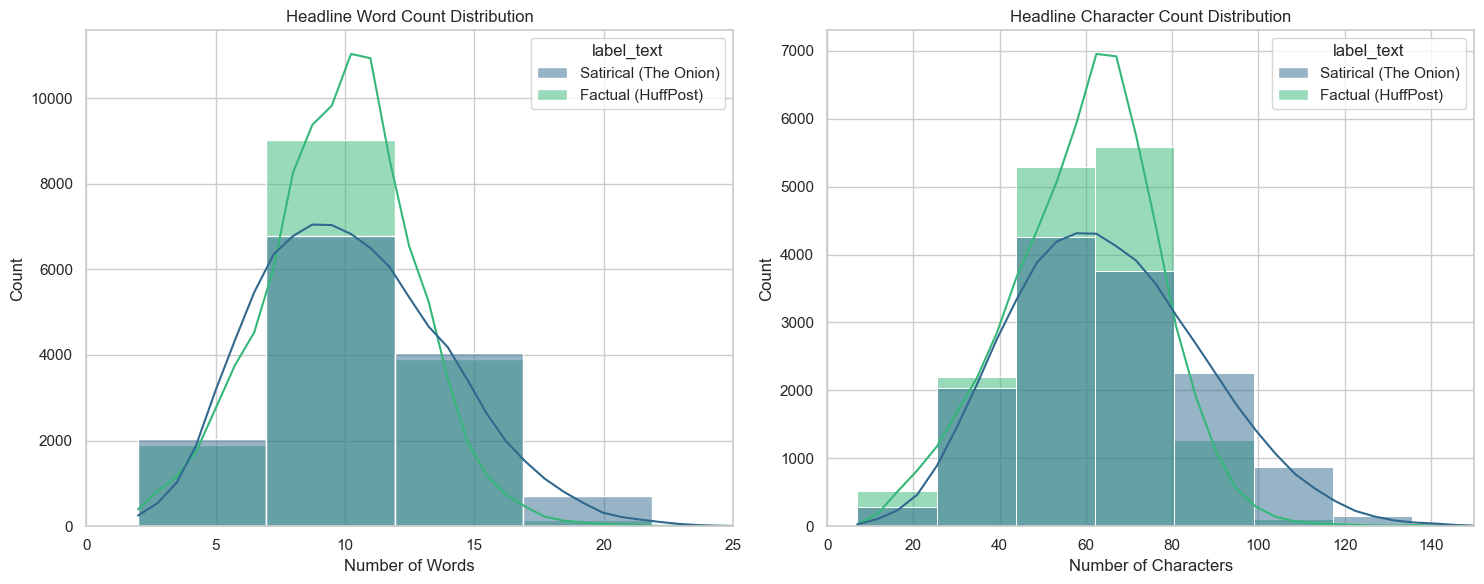

In [7]:
# Calculate word counts and character counts
df['word_count'] = df['headline'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['headline'].apply(lambda x: len(str(x)))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Word Count Distribution
sns.histplot(data=df, x='word_count', hue='label_text', bins=30, kde=True, ax=axes[0], palette='viridis')
axes[0].set_title('Headline Word Count Distribution')
axes[0].set_xlabel('Number of Words')

# Character Count Distribution
sns.histplot(data=df, x='char_count', hue='label_text', bins=50, kde=True, ax=axes[1], palette='viridis')
axes[1].set_title('Headline Character Count Distribution')
axes[1].set_xlabel('Number of Characters')

# Adjust layout and show plots
# restrict x-axis to focus on the majority of data points
axes[0].set_xlim(0, 25)
axes[1].set_xlim(0, 150)

plt.tight_layout()
plt.show()

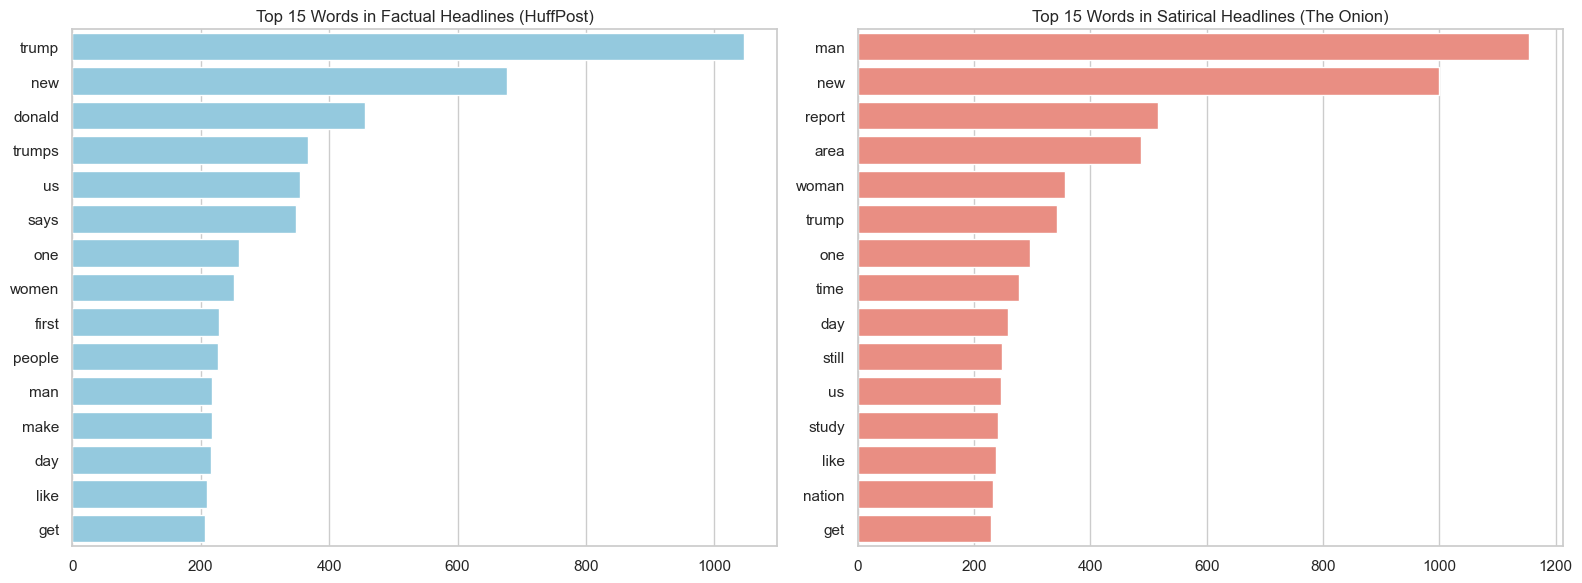

In [5]:
def get_top_ngrams(corpus, n=1, top_k=20):
    """Extracts top n-grams from a text corpus, ignoring stopwords."""
    vec = []
    for text in corpus:
        # Lowercase and remove punctuation
        text = re.sub(r'[^\w\s]', '', str(text).lower())
        words = text.split()
        words = [w for w in words if w not in stop_words]
        
        if n == 1:
            vec.extend(words)
        else:
            vec.extend([' '.join(words[i:i+n]) for i in range(len(words)-n+1)])
            
    counter = Counter(vec)
    return counter.most_common(top_k)

# Separate corpora
factual_corpus = df[df['is_sarcastic'] == 0]['headline']
satirical_corpus = df[df['is_sarcastic'] == 1]['headline']

# Get top unigrams
top_factual_words = get_top_ngrams(factual_corpus, n=1, top_k=15)
top_satirical_words = get_top_ngrams(satirical_corpus, n=1, top_k=15)

# Plotting Unigrams
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Factual
sns.barplot(x=[val for word, val in top_factual_words], 
            y=[word for word, val in top_factual_words], ax=axes[0], color='skyblue')
axes[0].set_title('Top 15 Words in Factual Headlines (HuffPost)')

# Satirical
sns.barplot(x=[val for word, val in top_satirical_words], 
            y=[word for word, val in top_satirical_words], ax=axes[1], color='salmon')
axes[1].set_title('Top 15 Words in Satirical Headlines (The Onion)')

plt.tight_layout()
plt.show()